In [ ]:
import pandas as pd
from scipy.stats import pointbiserialr
import numpy as np
import statsmodels.api as sm
!pip install statstests
from statstests.process import stepwise
!pip install scikit-learn
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from scipy import interpolate
from sklearn.preprocessing import LabelEncoder
from scipy.stats import pearsonr
from statstests.tests import shapiro_francia
from scipy.stats import norm
from scipy import stats

In [ ]:
df = pd.read_excel('/content/dados_escala.xlsx', sheet_name='data')
df["escala_binaria"] = df["escala"].map({"5x2":0, "6x1":1})

In [ ]:
df2023 = df[df['Ano'] == 2023].copy()
df2024 = df[df['Ano'] == 2024].copy()
df2025 = df[df['Ano'] == 2025].copy()

In [ ]:
corr, p_value = pointbiserialr(df["escala_binaria"], df["Absenteismo"])

print("Point-Biserial Correlation:", corr)
print("p-value:", p_value)

Point-Biserial Correlation: 0.12539285831502534
p-value: 0.15196850388218214


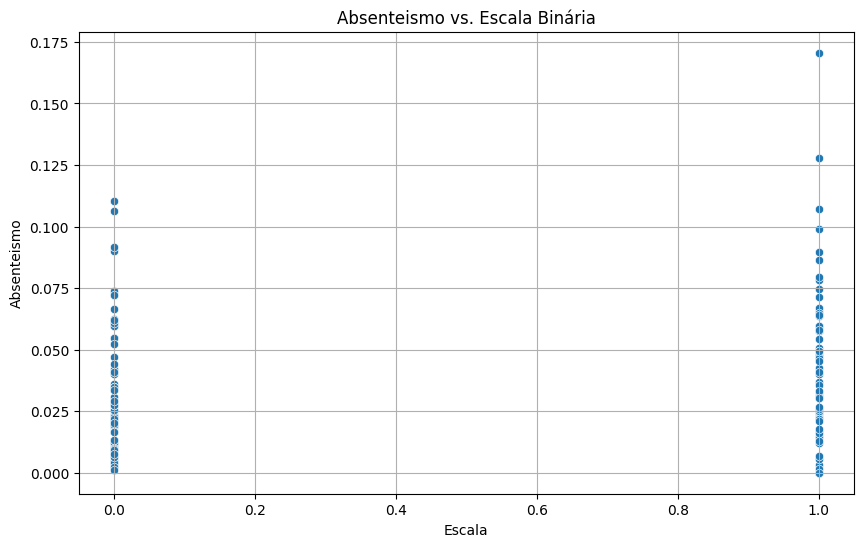

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='escala_binaria', y='Absenteismo', data=df)
plt.title('Absenteismo vs. Escala Binária')
plt.xlabel('Escala')
plt.ylabel('Absenteismo')
plt.grid(True)
plt.show()

In [ ]:
corr, p_value = pointbiserialr(df["escala_binaria"], df["Rotatividade"])

print("Point-Biserial Correlation:", corr)
print("p-value:", p_value)

Point-Biserial Correlation: 0.21182190345893168
p-value: 0.014759139441210397


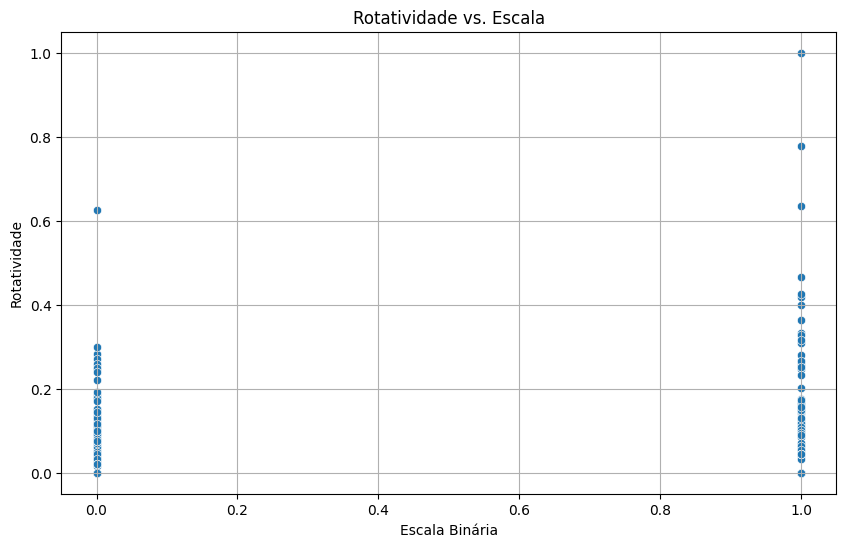

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='escala_binaria', y='Rotatividade', data=df)
plt.title('Rotatividade vs. Escala')
plt.xlabel('Escala Binária')
plt.ylabel('Rotatividade')
plt.grid(True)
plt.show()

In [ ]:
corr, p_value = pointbiserialr(df2023["escala_binaria"], df2023["Absenteismo"])

print("Point-Biserial Correlation:", corr)
print("p-value:", p_value)

Point-Biserial Correlation: -0.042238314042829773
p-value: 0.8184554910756283


In [ ]:
corr, p_value = pointbiserialr(df2023["escala_binaria"], df2023["Rotatividade"])

print("Point-Biserial Correlation:", corr)
print("p-value:", p_value)

Point-Biserial Correlation: 0.1307408159864295
p-value: 0.47570520251656095


In [ ]:
corr, p_value = pointbiserialr(df2024["escala_binaria"], df2024["Absenteismo"])

print("Point-Biserial Correlation:", corr)
print("p-value:", p_value)

Point-Biserial Correlation: 0.05303525983488892
p-value: 0.7694278968543683


In [ ]:
corr, p_value = pointbiserialr(df2024["escala_binaria"], df2024["Rotatividade"])

print("Point-Biserial Correlation:", corr)
print("p-value:", p_value)

Point-Biserial Correlation: 0.13969382244594122
p-value: 0.43813233584217337


In [ ]:
corr, p_value = pointbiserialr(df2025["escala_binaria"], df2025["Absenteismo"])

print("Point-Biserial Correlation:", corr)
print("p-value:", p_value)

Point-Biserial Correlation: 0.08989557347009026
p-value: 0.6131402920960553


In [ ]:
corr, p_value = pointbiserialr(df2025["escala_binaria"], df2025["Rotatividade"])

print("Point-Biserial Correlation:", corr)
print("p-value:", p_value)

In [ ]:
def matriz_confusao(predicts, observado, cutoff):

    values = predicts.values

    predicao_binaria = []

    for item in values:
        if item < cutoff:
            predicao_binaria.append(0)
        else:
            predicao_binaria.append(1)

    cm = confusion_matrix(predicao_binaria, observado)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.xlabel('True')
    plt.ylabel('Classified')
    plt.gca().invert_xaxis()
    plt.gca().invert_yaxis()
    plt.show()

    sensitividade = recall_score(observado, predicao_binaria, pos_label=1)
    especificidade = recall_score(observado, predicao_binaria, pos_label=0)
    acuracia = accuracy_score(observado, predicao_binaria)

    #Visualizando os principais indicadores desta matriz de confusão
    indicadores = pd.DataFrame({'Sensitividade':[sensitividade],
                                'Especificidade':[especificidade],
                                'Acurácia':[acuracia]})
    return indicadores


In [ ]:
def espec_sens(observado,predicts):

    # adicionar objeto com os valores dos predicts
    values = predicts.values

    # range dos cutoffs a serem analisados em steps de 0.01
    cutoffs = np.arange(0,1.01,0.01)

    # Listas que receberão os resultados de especificidade e sensitividade
    lista_sensitividade = []
    lista_especificidade = []

    for cutoff in cutoffs:

        predicao_binaria = []

        # Definindo resultado binário de acordo com o predict
        for item in values:
            if item >= cutoff:
                predicao_binaria.append(1)
            else:
                predicao_binaria.append(0)

        # Cálculo da sensitividade e especificidade no cutoff
        sensitividade = recall_score(observado, predicao_binaria, pos_label=1)
        especificidadee = recall_score(observado, predicao_binaria, pos_label=0)

        # Adicionar valores nas listas
        lista_sensitividade.append(sensitividade)
        lista_especificidade.append(especificidadee)

    # Criar dataframe com os resultados nos seus respectivos cutoffs
    resultado = pd.DataFrame({'cutoffs':cutoffs,'sensitividade':lista_sensitividade,'especificidade':lista_especificidade})
    return resultado

Regressão com Y escala

In [ ]:
df_reg_esc = pd.read_excel('regressao_escala.xlsx')

In [ ]:
df_reg_esc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7542 entries, 0 to 7541
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   cargo        7542 non-null   object 
 1   demitido     7542 non-null   int64  
 2   absenteismo  7542 non-null   float64
 3   escala       7542 non-null   int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 235.8+ KB


In [ ]:
df_reg_esc_dummies = pd.get_dummies(df_reg_esc,
                                       columns=['cargo'],
                                       dtype=int,
                                       drop_first=True)

In [ ]:
lista_colunas = list(df_reg_esc_dummies.drop(columns=['escala']).columns)
formula_dummies_modelo = ' + '.join(lista_colunas)
formula_dummies_modelo = "escala ~ " + formula_dummies_modelo
print("Fórmula utilizada: ",formula_dummies_modelo)

Fórmula utilizada:  escala ~ demitido + absenteismo + cargo_Atendente_De_Lanchonete + cargo_Auxiliar_De_Cozinha + cargo_Auxiliar_De_Expedicao + cargo_Auxiliar_De_Higienizacao + cargo_Auxiliar_De_Limpeza + cargo_Auxiliar_Massas_Conf_Panificacao + cargo_Auxiliar_Servicos_Gerais + cargo_Cozinheiro + cargo_Cozinheiro_Chefe + cargo_Encarregado_Operacional + cargo_Estoquista + cargo_Meio_Oficial_Cozinheiro + cargo_Motorista + cargo_Nutricionista_Supervisor_Operacional + cargo_Padeiro + cargo_Supervisor_Operacional


In [ ]:
modelo_logit = sm.Logit.from_formula(formula_dummies_modelo,
                                    df_reg_esc_dummies).fit()

Optimization terminated successfully.
         Current function value: 0.632236
         Iterations 6


In [ ]:
modelo_logit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 escala   No. Observations:                 7542
Model:                          Logit   Df Residuals:                     7523
Method:                           MLE   Df Model:                           18
Date:                Thu, 26 Feb 2026   Pseudo R-squ.:                 0.06773
Time:                        14:33:42   Log-Likelihood:                -4768.3
converged:                       True   LL-Null:                       -5114.8
Covariance Type:            nonrobust   LLR p-value:                1.835e-135
==============================================================================================================
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     -1.9708      0.540     -3.648      0.000      -3.029      -0.912
demitido                                       0.2918      0.056      5.176      0.000       0.181       0.402
absenteismo                                    0.8224      0.179      4.601      0.000       0.472       1.173
cargo_Atendente_De_Lanchonete                  0.5597      0.598      0.936      0.349      -0.613       1.732
cargo_Auxiliar_De_Cozinha                      2.2510      0.541      4.160      0.000       1.190       3.311
cargo_Auxiliar_De_Expedicao                    2.7919      0.581      4.807      0.000       1.654       3.930
cargo_Auxiliar_De_Higienizacao                 2.1686      0.556      3.903      0.000       1.079       3.258
cargo_Auxiliar_De_Limpeza                      1.4681      0.554      2.651      0.008       0.383       2.553
cargo_Auxiliar_Massas_Conf_Panificacao         2.4944      0.558      4.469      0.000       1.401       3.588
cargo_Auxiliar_Servicos_Gerais                 1.8731      0.554      3.383      0.001       0.788       2.958
cargo_Cozinheiro                               2.2704      0.545      4.168      0.000       1.203       3.338
cargo_Cozinheiro_Chefe                         0.4806      0.660      0.728      0.466      -0.813       1.774
cargo_Encarregado_Operacional                  1.1654      0.570      2.045      0.041       0.048       2.282
cargo_Estoquista                               0.4912      0.566      0.867      0.386      -0.619       1.601
cargo_Meio_Oficial_Cozinheiro                  2.3451      0.545      4.303      0.000       1.277       3.413
cargo_Motorista                                1.1362      0.580      1.959      0.050      -0.001       2.273
cargo_Nutricionista_Supervisor_Operacional    -0.5775      0.600     -0.963      0.336      -1.753       0.598
cargo_Padeiro                                  1.7169      0.656      2.616      0.009       0.431       3.003
cargo_Supervisor_Operacional                   0.6145      0.604      1.018      0.309      -0.569       1.798
==============================================================================================================
"""

In [ ]:
step_modelo_logit = stepwise(modelo_logit, pvalue_limit=0.05)

Regression type: Logit 

Estimating model...: 
 escala ~ Q('demitido') + Q('absenteismo') + Q('cargo_Atendente_De_Lanchonete') + Q('cargo_Auxiliar_De_Cozinha') + Q('cargo_Auxiliar_De_Expedicao') + Q('cargo_Auxiliar_De_Higienizacao') + Q('cargo_Auxiliar_De_Limpeza') + Q('cargo_Auxiliar_Massas_Conf_Panificacao') + Q('cargo_Auxiliar_Servicos_Gerais') + Q('cargo_Cozinheiro') + Q('cargo_Cozinheiro_Chefe') + Q('cargo_Encarregado_Operacional') + Q('cargo_Estoquista') + Q('cargo_Meio_Oficial_Cozinheiro') + Q('cargo_Motorista') + Q('cargo_Nutricionista_Supervisor_Operacional') + Q('cargo_Padeiro') + Q('cargo_Supervisor_Operacional')
Optimization terminated successfully.
         Current function value: 0.632236
         Iterations 6

 Discarding atribute "Q('cargo_Cozinheiro_Chefe')" with p-value equal to 0.4664178792494629 

Estimating model...: 
 escala ~ Q('demitido') + Q('absenteismo') + Q('cargo_Atendente_De_Lanchonete') + Q('cargo_Auxiliar_De_Cozinha') + Q('cargo_Auxiliar_De_Expedicao') +

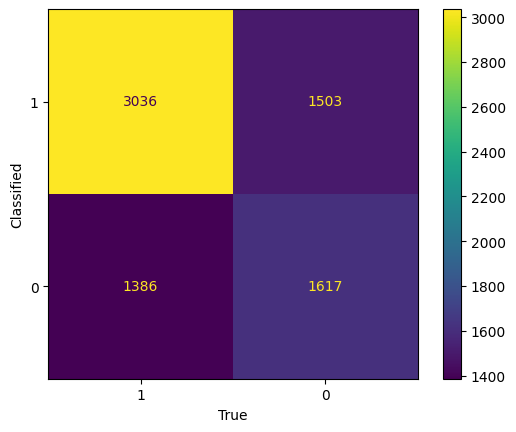

,Sensitividade,Especificidade,Acurácia
0,0.686567,0.518269,0.616945


In [ ]:
df_reg_esc_dummies['phat'] = step_modelo_logit.predict()

matriz_confusao(observado=df_reg_esc_dummies['escala'],
                predicts=df_reg_esc_dummies['phat'],
                cutoff=0.62)


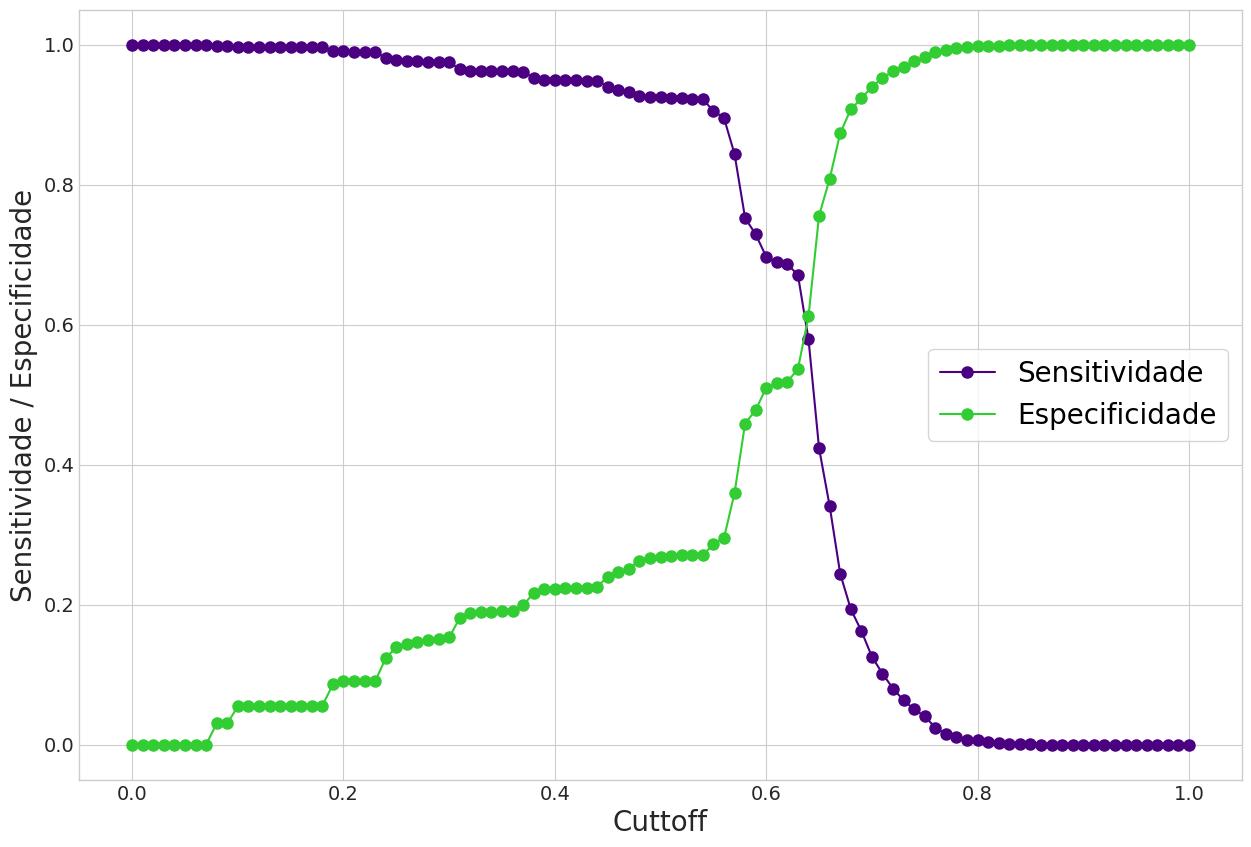

In [ ]:
dados_plotagem = espec_sens(observado = df_reg_esc_dummies['escala'],
                            predicts = df_reg_esc_dummies['phat'])

plt.figure(figsize=(15,10))
with plt.style.context('seaborn-v0_8-whitegrid'):
    plt.plot(dados_plotagem.cutoffs,dados_plotagem.sensitividade, marker='o',
         color='indigo', markersize=8)
    plt.plot(dados_plotagem.cutoffs,dados_plotagem.especificidade, marker='o',
         color='limegreen', markersize=8)
plt.xlabel('Cuttoff', fontsize=20)
plt.ylabel('Sensitividade / Especificidade', fontsize=20)
plt.xticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.legend(['Sensitividade', 'Especificidade'], fontsize=20)
plt.show()


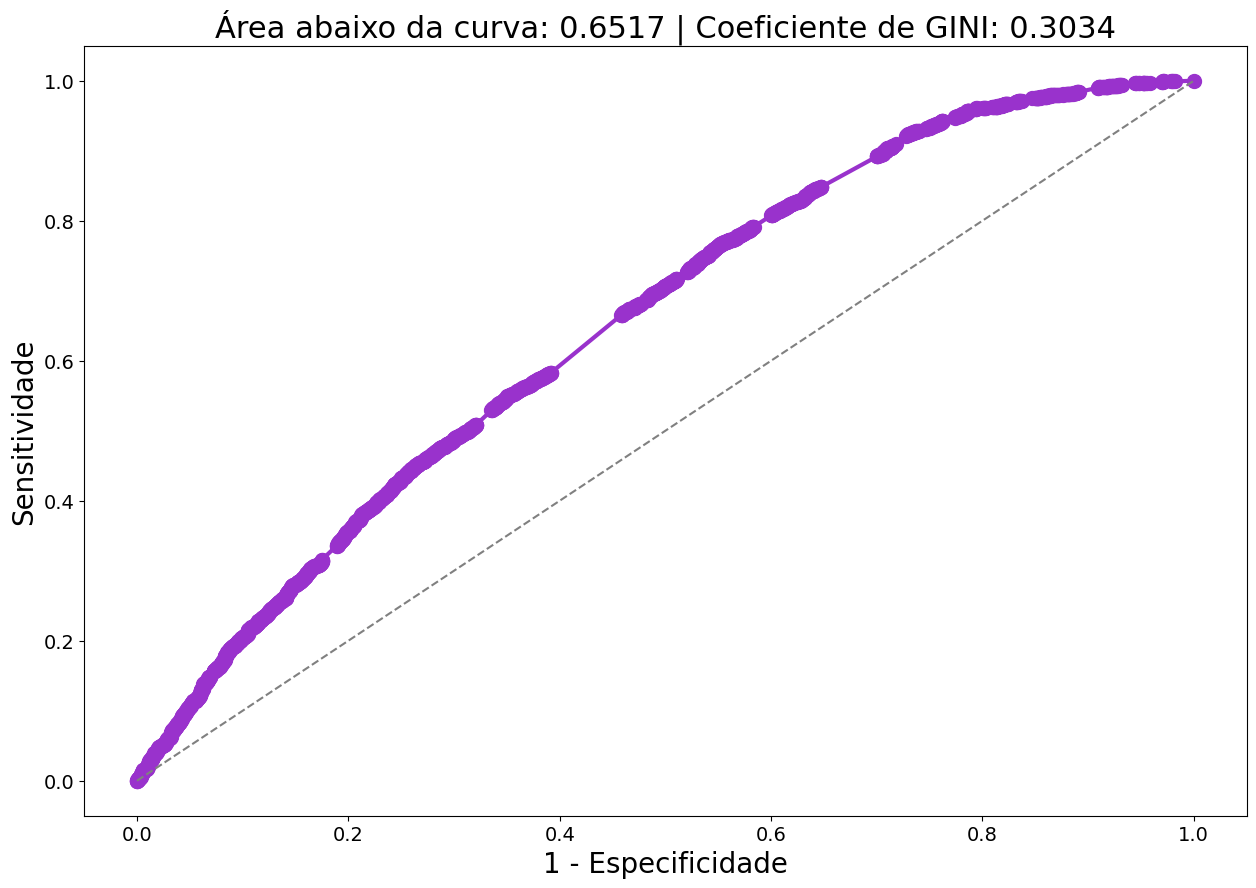

In [ ]:
# Função 'roc_curve' do pacote 'metrics' do sklearn

fpr, tpr, thresholds =roc_curve(df_reg_esc_dummies['escala'],
                                df_reg_esc_dummies['phat'])
roc_auc = auc(fpr, tpr)

# Cálculo do coeficiente de GINI
gini = (roc_auc - 0.5)/(0.5)

# Plotando a curva ROC
plt.figure(figsize=(15,10))
plt.plot(fpr, tpr, marker='o', color='darkorchid', markersize=10, linewidth=3)
plt.plot(fpr, fpr, color='gray', linestyle='dashed')
plt.title('Área abaixo da curva: %g' % round(roc_auc, 4) +
          ' | Coeficiente de GINI: %g' % round(gini, 4), fontsize=22)
plt.xlabel('1 - Especificidade', fontsize=20)
plt.ylabel('Sensitividade', fontsize=20)
plt.xticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.show()

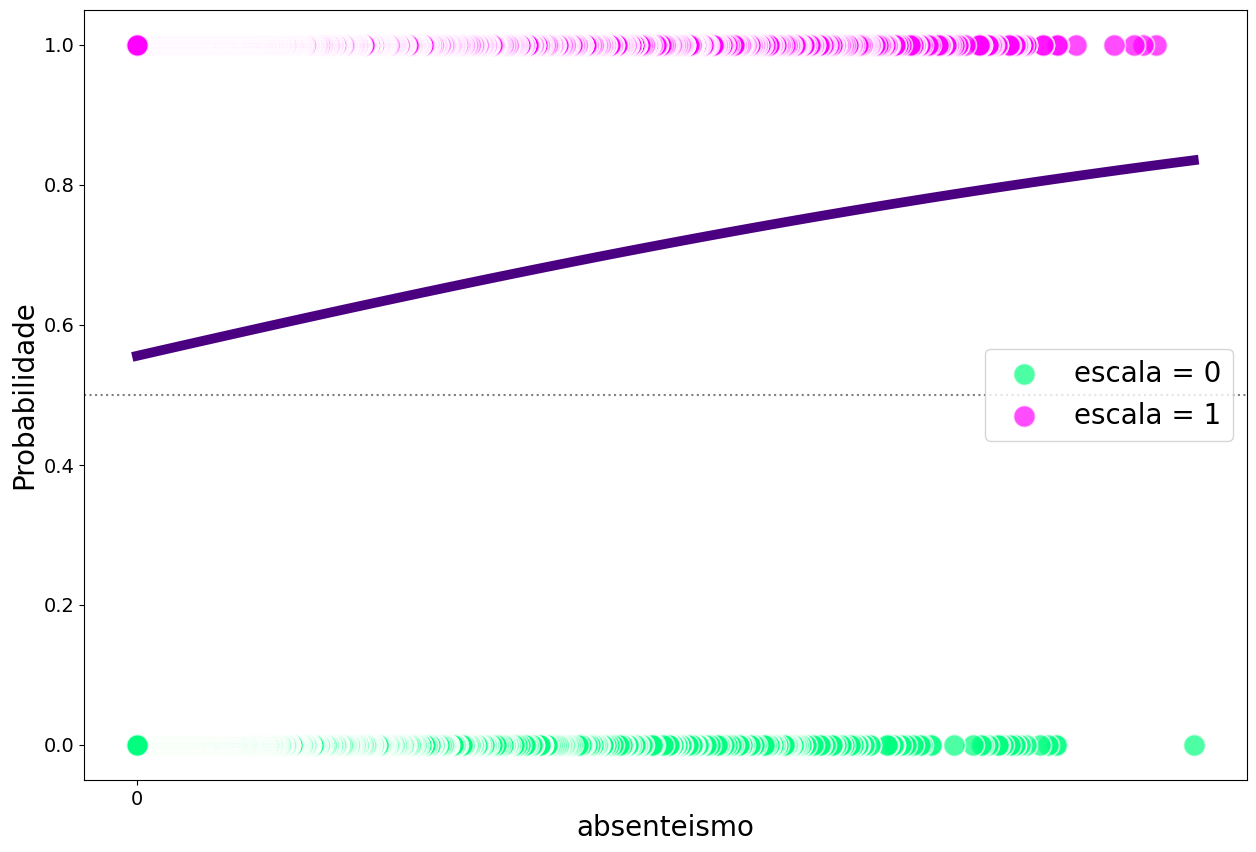

In [ ]:
plt.figure(figsize=(15,10))
sns.scatterplot(x=df_reg_esc_dummies['absenteismo'][df_reg_esc_dummies['escala'] == 0],
                y=df_reg_esc_dummies['escala'][df_reg_esc_dummies['escala'] == 0],
                color='springgreen', alpha=0.7, s=250, label='escala = 0')
sns.scatterplot(x=df_reg_esc_dummies['absenteismo'][df_reg_esc_dummies['escala'] == 1],
                y=df_reg_esc_dummies['escala'][df_reg_esc_dummies['escala'] == 1],
                color='magenta', alpha=0.7, s=250, label='escala = 1')
sns.regplot(x=df_reg_esc_dummies['absenteismo'], y=df_reg_esc_dummies['escala'],
            logistic=True, ci=None, scatter=False,
            line_kws={'color': 'indigo', 'linewidth': 7})
plt.axhline(y = 0.5, color = 'grey', linestyle = ':')
plt.xlabel('absenteismo', fontsize=20)
plt.ylabel('Probabilidade', fontsize=20)
plt.xticks(np.arange(df_reg_esc_dummies['absenteismo'].min(),
                     df_reg_esc_dummies['absenteismo'].max() + 0.01, 3),
           fontsize=14)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.legend(fontsize=20, loc='center right')
plt.show()

In [ ]:
def calculate_log_odds(model_results):
  """
  Calculates the log odds for each coefficient in a logistic regression model.

  Args:
    model_results: The results object from a statsmodels logistic regression model.

  Returns:
    A pandas Series containing the log odds for each coefficient.
  """
  return model_results.params

# Calculate and print the log odds using the step_modelo
log_odds = calculate_log_odds(step_modelo_logit)

# Convert the log odds Series to a DataFrame for table display
log_odds_df = pd.DataFrame({'Variable': log_odds.index, 'Log Odds': log_odds.values})

# Calculate the odds ratios by exponentiating the log odds
log_odds_df['Odds Ratio'] = np.exp(log_odds_df['Log Odds'])

print("Log Odds and Odds Ratios:")
display(log_odds_df)


Log Odds and Odds Ratios:


,Variable,Log Odds,Odds Ratio
0,Intercept,-1.472785,0.229286
1,Q('demitido'),0.293506,1.341121
2,Q('absenteismo'),0.819919,2.270316
3,Q('cargo_Auxiliar_De_Cozinha'),1.751991,5.766070
4,Q('cargo_Auxiliar_De_Expedicao'),2.292994,9.904543
5,Q('cargo_Auxiliar_De_Higienizacao'),1.669511,5.309568
6,Q('cargo_Auxiliar_De_Limpeza'),0.969134,2.635662
7,Q('cargo_Auxiliar_Massas_Conf_Panificacao'),1.995355,7.354815
8,Q('cargo_Auxiliar_Servicos_Gerais'),1.373978,3.951035
9,Q('cargo_Cozinheiro'),1.771581,5.880141


Regressão com Y Demitido

In [ ]:
df_reg_dem = pd.read_excel('regressao_escala.xlsx')

In [ ]:
df_reg_dem_dummies = pd.get_dummies(df_reg_dem,
                                       columns=['cargo'],
                                       dtype=int,
                                       drop_first=True)

In [ ]:
lista_colunas = list(df_reg_dem_dummies.drop(columns=['demitido']).columns)
formula_dummies_modelo2 = ' + '.join(lista_colunas)
formula_dummies_modelo2 = "demitido ~ " + formula_dummies_modelo2
print("Fórmula utilizada: ",formula_dummies_modelo2)

Fórmula utilizada:  demitido ~ absenteismo + escala + cargo_Atendente_De_Lanchonete + cargo_Auxiliar_De_Cozinha + cargo_Auxiliar_De_Expedicao + cargo_Auxiliar_De_Higienizacao + cargo_Auxiliar_De_Limpeza + cargo_Auxiliar_Massas_Conf_Panificacao + cargo_Auxiliar_Servicos_Gerais + cargo_Cozinheiro + cargo_Cozinheiro_Chefe + cargo_Encarregado_Operacional + cargo_Estoquista + cargo_Meio_Oficial_Cozinheiro + cargo_Motorista + cargo_Nutricionista_Supervisor_Operacional + cargo_Padeiro + cargo_Supervisor_Operacional


In [ ]:
modelo_logit2 = sm.Logit.from_formula(formula_dummies_modelo2,
                                    df_reg_esc_dummies).fit()

Optimization terminated successfully.
         Current function value: 0.519303
         Iterations 8


In [ ]:
modelo_logit2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               demitido   No. Observations:                 7542
Model:                          Logit   Df Residuals:                     7523
Method:                           MLE   Df Model:                           18
Date:                Thu, 26 Feb 2026   Pseudo R-squ.:                  0.1447
Time:                        15:02:00   Log-Likelihood:                -3916.6
converged:                       True   LL-Null:                       -4579.2
Covariance Type:            nonrobust   LLR p-value:                1.613e-270
==============================================================================================================
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                     -0.9717      0.407     -2.389      0.017      -1.769      -0.174
absenteismo                                   12.0874      0.620     19.494      0.000      10.872      13.303
escala                                         0.2548      0.057      4.465      0.000       0.143       0.367
cargo_Atendente_De_Lanchonete                  1.5636      0.481      3.254      0.001       0.622       2.506
cargo_Auxiliar_De_Cozinha                      1.2365      0.409      3.021      0.003       0.434       2.039
cargo_Auxiliar_De_Expedicao                    1.3819      0.481      2.874      0.004       0.439       2.324
cargo_Auxiliar_De_Higienizacao                 1.4439      0.437      3.302      0.001       0.587       2.301
cargo_Auxiliar_De_Limpeza                      1.2023      0.430      2.795      0.005       0.359       2.045
cargo_Auxiliar_Massas_Conf_Panificacao         1.6719      0.445      3.760      0.000       0.800       2.543
cargo_Auxiliar_Servicos_Gerais                 1.6944      0.435      3.891      0.000       0.841       2.548
cargo_Cozinheiro                               0.6694      0.414      1.616      0.106      -0.143       1.482
cargo_Cozinheiro_Chefe                         0.6335      0.523      1.212      0.225      -0.391       1.658
cargo_Encarregado_Operacional                  0.0165      0.447      0.037      0.971      -0.860       0.893
cargo_Estoquista                               1.5403      0.447      3.445      0.001       0.664       2.417
cargo_Meio_Oficial_Cozinheiro                  1.0963      0.415      2.640      0.008       0.282       1.910
cargo_Motorista                                0.0898      0.461      0.195      0.845      -0.813       0.992
cargo_Nutricionista_Supervisor_Operacional     0.6962      0.432      1.610      0.107      -0.151       1.544
cargo_Padeiro                                  0.3166      0.564      0.562      0.574      -0.788       1.421
cargo_Supervisor_Operacional                   0.9187      0.470      1.955      0.051      -0.003       1.840
==============================================================================================================
"""

In [ ]:
step_modelo_logit2 = stepwise(modelo_logit2, pvalue_limit=0.05)

Regression type: Logit 

Estimating model...: 
 demitido ~ Q('absenteismo') + Q('escala') + Q('cargo_Atendente_De_Lanchonete') + Q('cargo_Auxiliar_De_Cozinha') + Q('cargo_Auxiliar_De_Expedicao') + Q('cargo_Auxiliar_De_Higienizacao') + Q('cargo_Auxiliar_De_Limpeza') + Q('cargo_Auxiliar_Massas_Conf_Panificacao') + Q('cargo_Auxiliar_Servicos_Gerais') + Q('cargo_Cozinheiro') + Q('cargo_Cozinheiro_Chefe') + Q('cargo_Encarregado_Operacional') + Q('cargo_Estoquista') + Q('cargo_Meio_Oficial_Cozinheiro') + Q('cargo_Motorista') + Q('cargo_Nutricionista_Supervisor_Operacional') + Q('cargo_Padeiro') + Q('cargo_Supervisor_Operacional')
Optimization terminated successfully.
         Current function value: 0.519303
         Iterations 8

 Discarding atribute "Q('cargo_Encarregado_Operacional')" with p-value equal to 0.9705661326901671 

Estimating model...: 
 demitido ~ Q('absenteismo') + Q('escala') + Q('cargo_Atendente_De_Lanchonete') + Q('cargo_Auxiliar_De_Cozinha') + Q('cargo_Auxiliar_De_Expedi

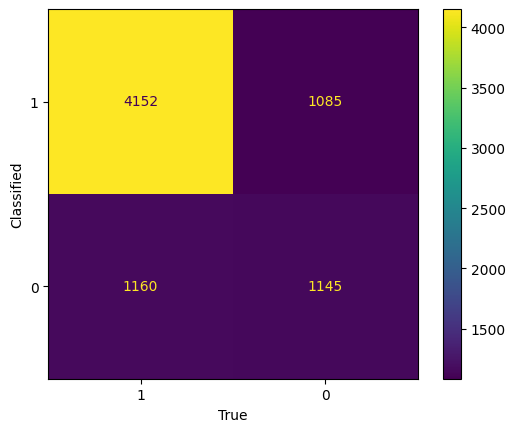

,Sensitividade,Especificidade,Acurácia
0,0.781627,0.513453,0.702334


In [ ]:
df_reg_dem_dummies['phat'] = step_modelo_logit2.predict()

matriz_confusao(observado=df_reg_dem_dummies['demitido'],
                predicts=df_reg_dem_dummies['phat'],
                cutoff=0.62)

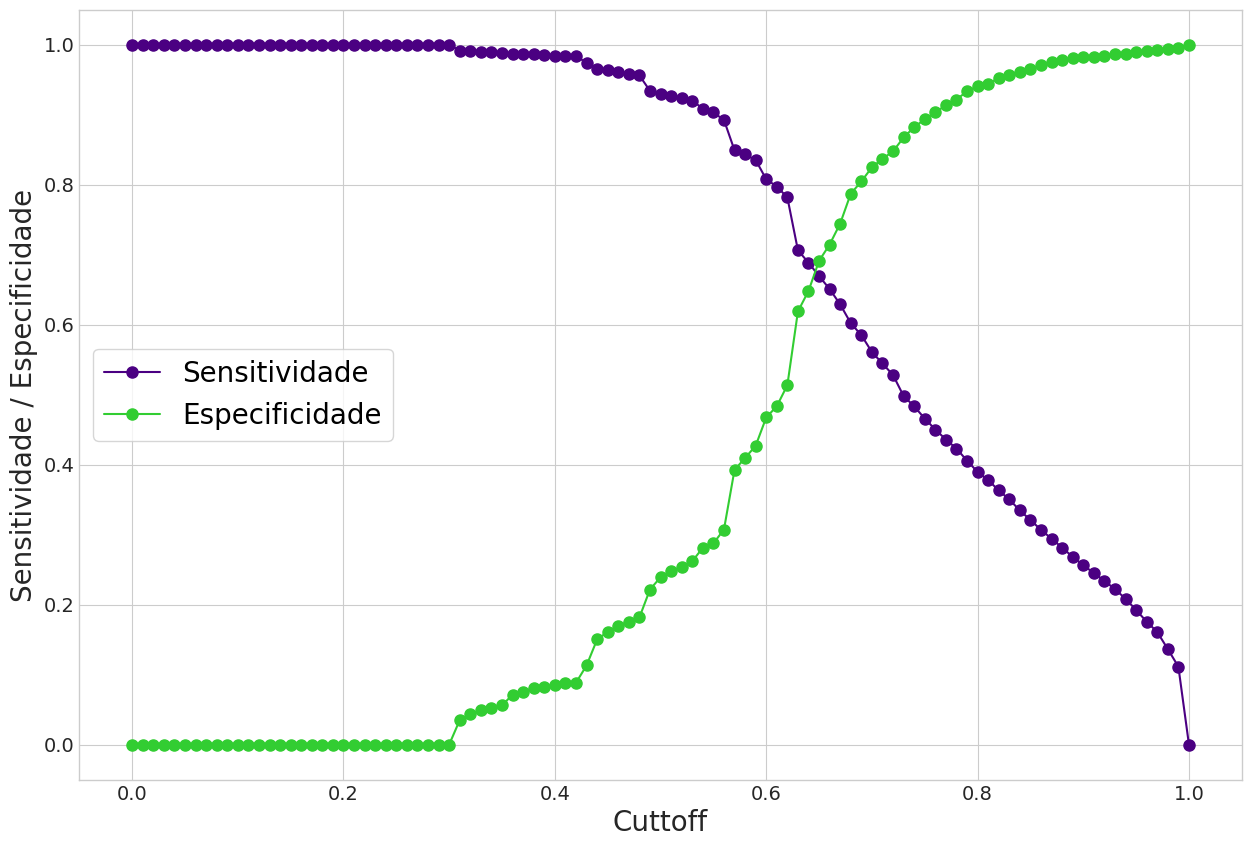

In [ ]:
dados_plotagem2 = espec_sens(observado = df_reg_dem_dummies['demitido'],
                            predicts = df_reg_dem_dummies['phat'])

plt.figure(figsize=(15,10))
with plt.style.context('seaborn-v0_8-whitegrid'):
    plt.plot(dados_plotagem2.cutoffs,dados_plotagem2.sensitividade, marker='o',
         color='indigo', markersize=8)
    plt.plot(dados_plotagem2.cutoffs,dados_plotagem2.especificidade, marker='o',
         color='limegreen', markersize=8)
plt.xlabel('Cuttoff', fontsize=20)
plt.ylabel('Sensitividade / Especificidade', fontsize=20)
plt.xticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.legend(['Sensitividade', 'Especificidade'], fontsize=20)
plt.show()

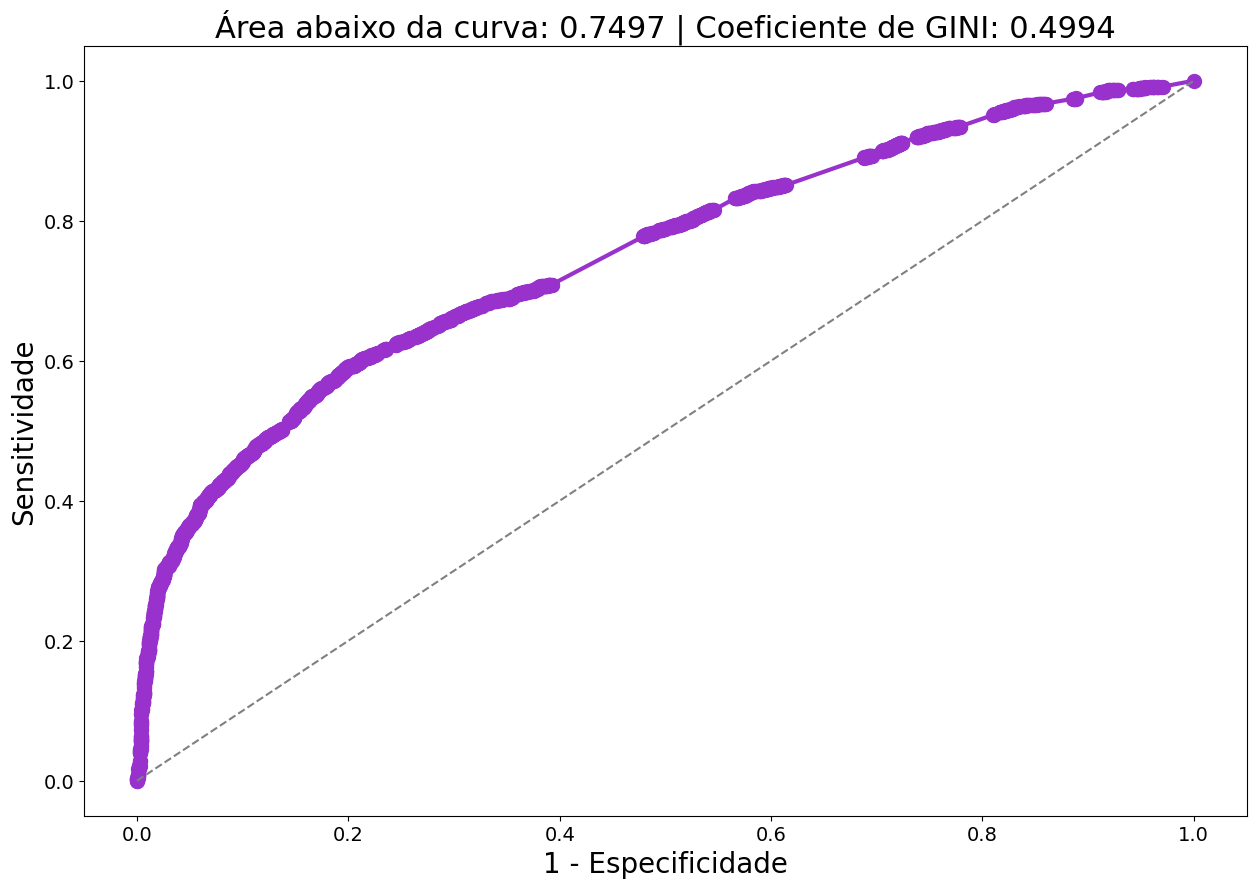

In [ ]:
fpr, tpr, thresholds =roc_curve(df_reg_dem_dummies['demitido'],
                                df_reg_dem_dummies['phat'])
roc_auc = auc(fpr, tpr)

# Cálculo do coeficiente de GINI
gini = (roc_auc - 0.5)/(0.5)

# Plotando a curva ROC
plt.figure(figsize=(15,10))
plt.plot(fpr, tpr, marker='o', color='darkorchid', markersize=10, linewidth=3)
plt.plot(fpr, fpr, color='gray', linestyle='dashed')
plt.title('Área abaixo da curva: %g' % round(roc_auc, 4) +
          ' | Coeficiente de GINI: %g' % round(gini, 4), fontsize=22)
plt.xlabel('1 - Especificidade', fontsize=20)
plt.ylabel('Sensitividade', fontsize=20)
plt.xticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.show()

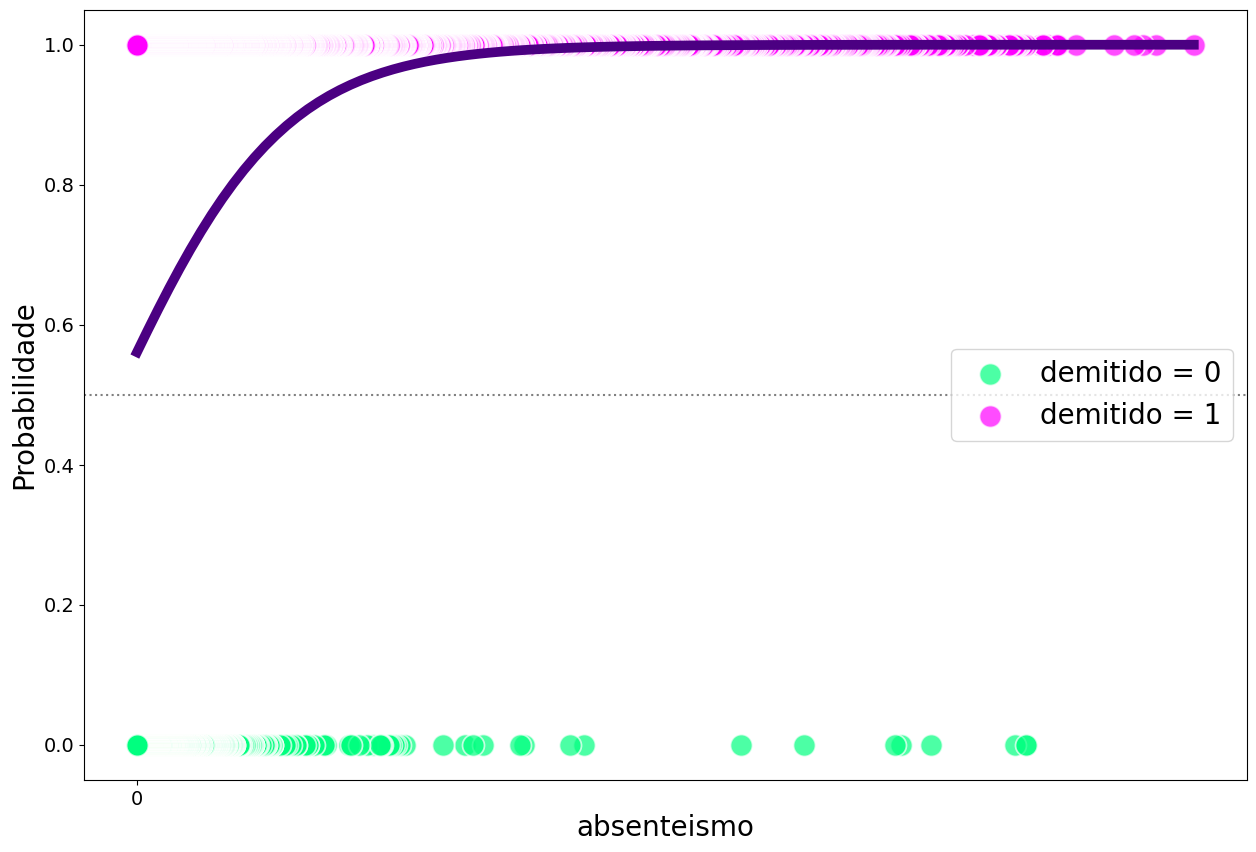

In [ ]:
plt.figure(figsize=(15,10))
sns.scatterplot(x=df_reg_esc_dummies['absenteismo'][df_reg_esc_dummies['demitido'] == 0],
                y=df_reg_esc_dummies['demitido'][df_reg_esc_dummies['demitido'] == 0],
                color='springgreen', alpha=0.7, s=250, label='demitido = 0')
sns.scatterplot(x=df_reg_esc_dummies['absenteismo'][df_reg_esc_dummies['demitido'] == 1],
                y=df_reg_esc_dummies['demitido'][df_reg_esc_dummies['demitido'] == 1],
                color='magenta', alpha=0.7, s=250, label='demitido = 1')
sns.regplot(x=df_reg_esc_dummies['absenteismo'], y=df_reg_esc_dummies['demitido'],
            logistic=True, ci=None, scatter=False,
            line_kws={'color': 'indigo', 'linewidth': 7})
plt.axhline(y = 0.5, color = 'grey', linestyle = ':')
plt.xlabel('absenteismo', fontsize=20)
plt.ylabel('Probabilidade', fontsize=20)
plt.xticks(np.arange(df_reg_esc_dummies['absenteismo'].min(),
                     df_reg_esc_dummies['absenteismo'].max() + 0.01, 3),
           fontsize=14)
plt.yticks(np.arange(0, 1.1, 0.2), fontsize=14)
plt.legend(fontsize=20, loc='center right')
plt.show()

In [ ]:
def calculate_log_odds(model_results):
  """
  Calculates the log odds for each coefficient in a logistic regression model.

  Args:
    model_results: The results object from a statsmodels logistic regression model.

  Returns:
    A pandas Series containing the log odds for each coefficient.
  """
  return model_results.params

# Calculate and print the log odds using the step_modelo
log_odds = calculate_log_odds(step_modelo_logit2)

# Convert the log odds Series to a DataFrame for table display
log_odds_df = pd.DataFrame({'Variable': log_odds.index, 'Log Odds': log_odds.values})

# Calculate the odds ratios by exponentiating the log odds
log_odds_df['Odds Ratio'] = np.exp(log_odds_df['Log Odds'])

print("Log Odds and Odds Ratios:")
display(log_odds_df)

Log Odds and Odds Ratios:


,Variable,Log Odds,Odds Ratio
0,Intercept,-0.831939,0.435205
1,Q('absenteismo'),12.101075,180065.345708
2,Q('escala'),0.253519,1.288552
3,Q('cargo_Atendente_De_Lanchonete'),1.423850,4.153081
4,Q('cargo_Auxiliar_De_Cozinha'),1.097072,2.995382
5,Q('cargo_Auxiliar_De_Expedicao'),1.242690,3.464922
6,Q('cargo_Auxiliar_De_Higienizacao'),1.304399,3.685474
7,Q('cargo_Auxiliar_De_Limpeza'),1.062721,2.894234
8,Q('cargo_Auxiliar_Massas_Conf_Panificacao'),1.532493,4.629706
9,Q('cargo_Auxiliar_Servicos_Gerais'),1.555046,4.735303


Regressão Linear com Dummies

In [ ]:
df_regressao_linear = pd.read_excel('dados_escala.xlsx', sheet_name = 'data')
df_regressao_linear

,escala,cargo,absenteismo,rotatividade,tempo_casa,ano
0,5x2,Acougueiro,0.0134,0.0000,9.52,2023
1,5x2,Acougueiro,0.0233,0.6250,8.40,2024
2,5x2,Acougueiro,0.0211,0.0486,9.40,2025
3,5x2,Acougueiro,0.0111,0.0417,13.03,2026
4,6x1,Acougueiro,0.0000,0.0000,1.25,2023
...,...,...,...,...,...,...
127,5x2,Supervisor_Operacional,0.0075,0.0213,5.39,2026
128,6x1,Supervisor_Operacional,0.0267,0.4250,0.77,2023
129,6x1,Supervisor_Operacional,0.0015,0.7778,0.91,2024
130,6x1,Supervisor_Operacional,0.0066,0.6357,0.72,2025


<Figure size 2000x1000 with 0 Axes>

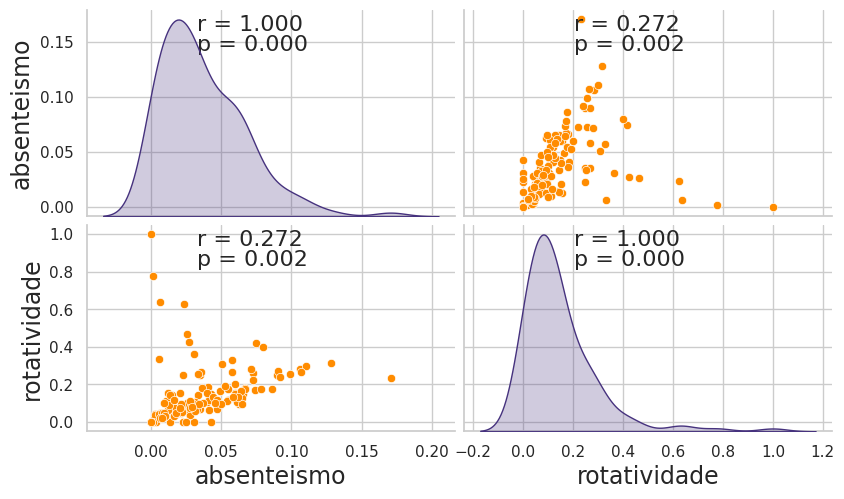

In [ ]:
def corrfunc(x, y, **kws):
    (r, p) = pearsonr(x, y)
    ax = plt.gca()
    ax.annotate("r = {:.3f}".format(r),
                xy=(.30, .9), xycoords=ax.transAxes, fontsize=16)
    ax.annotate("p = {:.3f}".format(p),
                xy=(.30, .8), xycoords=ax.transAxes, fontsize=16)

# Configuração do gráfico
sns.set(style="whitegrid", palette="viridis")

plt.figure(figsize=(20,10))
graph = sns.pairplot(df_regressao_linear.loc[:,'absenteismo':'rotatividade'], diag_kind="kde",
                     plot_kws={"color": "darkorange"},
                     height=2.5, aspect=1.7)
graph.map(corrfunc)
for ax in graph.axes.flat:
    ax.set_xlabel(ax.get_xlabel(), fontsize=17)
    ax.set_ylabel(ax.get_ylabel(), fontsize=17)
plt.show()

In [ ]:
df_regressao_linear_dummies = pd.get_dummies(df_regressao_linear, columns=['escala', 'cargo', 'ano'],
                                       dtype=int,
                                       drop_first=True)

df_regressao_linear_dummies

,absenteismo,rotatividade,tempo_casa,escala_6x1,cargo_Atendente_De_Lanchonete,cargo_Auxiliar_De_Cozinha,cargo_Auxiliar_De_Expedicao,cargo_Auxiliar_De_Higienizacao,cargo_Auxiliar_De_Limpeza,cargo_Auxiliar_Massas_Conf_Panificacao,...,cargo_Encarregado_Operacional,cargo_Estoquista,cargo_Meio_Oficial_Cozinheiro,cargo_Motorista,cargo_Nutricionista_Supervisor_Operacional,cargo_Padeiro,cargo_Supervisor_Operacional,ano_2024,ano_2025,ano_2026
0,0.0134,0.0000,9.52,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.0233,0.6250,8.40,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0.0211,0.0486,9.40,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,0.0111,0.0417,13.03,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0.0000,0.0000,1.25,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,0.0075,0.0213,5.39,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
128,0.0267,0.4250,0.77,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
129,0.0015,0.7778,0.91,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,0
130,0.0066,0.6357,0.72,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0


In [ ]:
# In[8.4]: Estimação do modelo de regressão múltipla com n-1 dummies

# Definição da fórmula utilizada no modelo
lista_colunas = list(df_regressao_linear_dummies.drop(columns=['absenteismo']).columns)
formula_dummies_modelo = ' + '.join(lista_colunas)
formula_dummies_modelo = "absenteismo ~ " + formula_dummies_modelo

# Estimação
modelo_planosaude = sm.OLS.from_formula(formula_dummies_modelo,
                                        df_regressao_linear_dummies).fit()

# Parâmetros do modelo
modelo_planosaude.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            absenteismo   R-squared:                       0.638
Model:                            OLS   Adj. R-squared:                  0.565
Method:                 Least Squares   F-statistic:                     8.721
Date:                Thu, 26 Feb 2026   Prob (F-statistic):           1.89e-15
Time:                        17:59:55   Log-Likelihood:                 341.88
No. Observations:                 132   AIC:                            -637.8
Df Residuals:                     109   BIC:                            -571.4
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
==============================================================================================================
                                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                      0.0174      0.010      1.795      0.075      -0.002       0.037
rotatividade                                   0.0220      0.015      1.507      0.135      -0.007       0.051
tempo_casa                                    -0.0011      0.001     -1.342      0.182      -0.003       0.001
escala_6x1                                     0.0058      0.004      1.601      0.112      -0.001       0.013
cargo_Atendente_De_Lanchonete                  0.0146      0.011      1.374      0.172      -0.006       0.036
cargo_Auxiliar_De_Cozinha                      0.0364      0.010      3.522      0.001       0.016       0.057
cargo_Auxiliar_De_Expedicao                    0.0667      0.010      6.400      0.000       0.046       0.087
cargo_Auxiliar_De_Higienizacao                 0.0351      0.010      3.409      0.001       0.015       0.056
cargo_Auxiliar_De_Limpeza                      0.0232      0.011      2.162      0.033       0.002       0.044
cargo_Auxiliar_Massas_Conf_Panificacao         0.0531      0.011      5.008      0.000       0.032       0.074
cargo_Auxiliar_Servicos_Gerais                 0.0289      0.011      2.640      0.010       0.007       0.051
cargo_Cozinheiro                               0.0109      0.010      1.085      0.280      -0.009       0.031
cargo_Cozinheiro_Chefe                         0.0163      0.011      1.489      0.139      -0.005       0.038
cargo_Encarregado_Operacional                  0.0039      0.011      0.348      0.729      -0.018       0.026
cargo_Estoquista                               0.0186      0.011      1.752      0.083      -0.002       0.040
cargo_Meio_Oficial_Cozinheiro                  0.0212      0.011      1.999      0.048       0.000       0.042
cargo_Motorista                               -0.0036      0.011     -0.334      0.739      -0.025       0.018
cargo_Nutricionista_Supervisor_Operacional    -0.0120      0.011     -1.095      0.276      -0.034       0.010
cargo_Padeiro                                  0.0076      0.012      0.651      0.516      -0.015       0.031
cargo_Supervisor_Operacional                  -0.0119      0.010     -1.138      0.258      -0.033       0.009
ano_2024                                       0.0021      0.005      0.417      0.677      -0.008       0.012
ano_2025                                       0.0013      0.005      0.256      0.799      -0.009       0.011
ano_2026                                      -0.0049      0.005     -0.965      0.337      -0.015       0.005
==============================================================================
Omnibus:                       66.807   Durbin-Watson:                   2.055
Prob(Omnibus):                  0.000  

In [ ]:
# Estimação do modelo por meio do procedimento Stepwise
modelo_step_planosaude = stepwise(modelo_planosaude, pvalue_limit=0.05)

# Teste de Shapiro-Francia: interpretação
teste_sf = shapiro_francia(modelo_step_planosaude.resid) #criação do objeto 'teste_sf'
teste_sf = teste_sf.items() #retorna o grupo de pares de valores-chave no dicionário
method, statistics_W, statistics_z, p = teste_sf #definição dos elementos da lista (tupla)
print('Statistics W=%.5f, p-value=%.6f' % (statistics_W[1], p[1]))
alpha = 0.05 #nível de significância
if p[1] > alpha:
	print('Não se rejeita H0 - Distribuição aderente à normalidade')
else:
	print('Rejeita-se H0 - Distribuição não aderente à normalidade')

Regression type: OLS 

Estimating model...: 
 absenteismo ~ Q('rotatividade') + Q('tempo_casa') + Q('escala_6x1') + Q('cargo_Atendente_De_Lanchonete') + Q('cargo_Auxiliar_De_Cozinha') + Q('cargo_Auxiliar_De_Expedicao') + Q('cargo_Auxiliar_De_Higienizacao') + Q('cargo_Auxiliar_De_Limpeza') + Q('cargo_Auxiliar_Massas_Conf_Panificacao') + Q('cargo_Auxiliar_Servicos_Gerais') + Q('cargo_Cozinheiro') + Q('cargo_Cozinheiro_Chefe') + Q('cargo_Encarregado_Operacional') + Q('cargo_Estoquista') + Q('cargo_Meio_Oficial_Cozinheiro') + Q('cargo_Motorista') + Q('cargo_Nutricionista_Supervisor_Operacional') + Q('cargo_Padeiro') + Q('cargo_Supervisor_Operacional') + Q('ano_2024') + Q('ano_2025') + Q('ano_2026')

 Discarding atribute "Q('ano_2025')" with p-value equal to 0.7987607088992394 

Estimating model...: 
 absenteismo ~ Q('rotatividade') + Q('tempo_casa') + Q('escala_6x1') + Q('cargo_Atendente_De_Lanchonete') + Q('cargo_Auxiliar_De_Cozinha') + Q('cargo_Auxiliar_De_Expedicao') + Q('cargo_Auxiliar

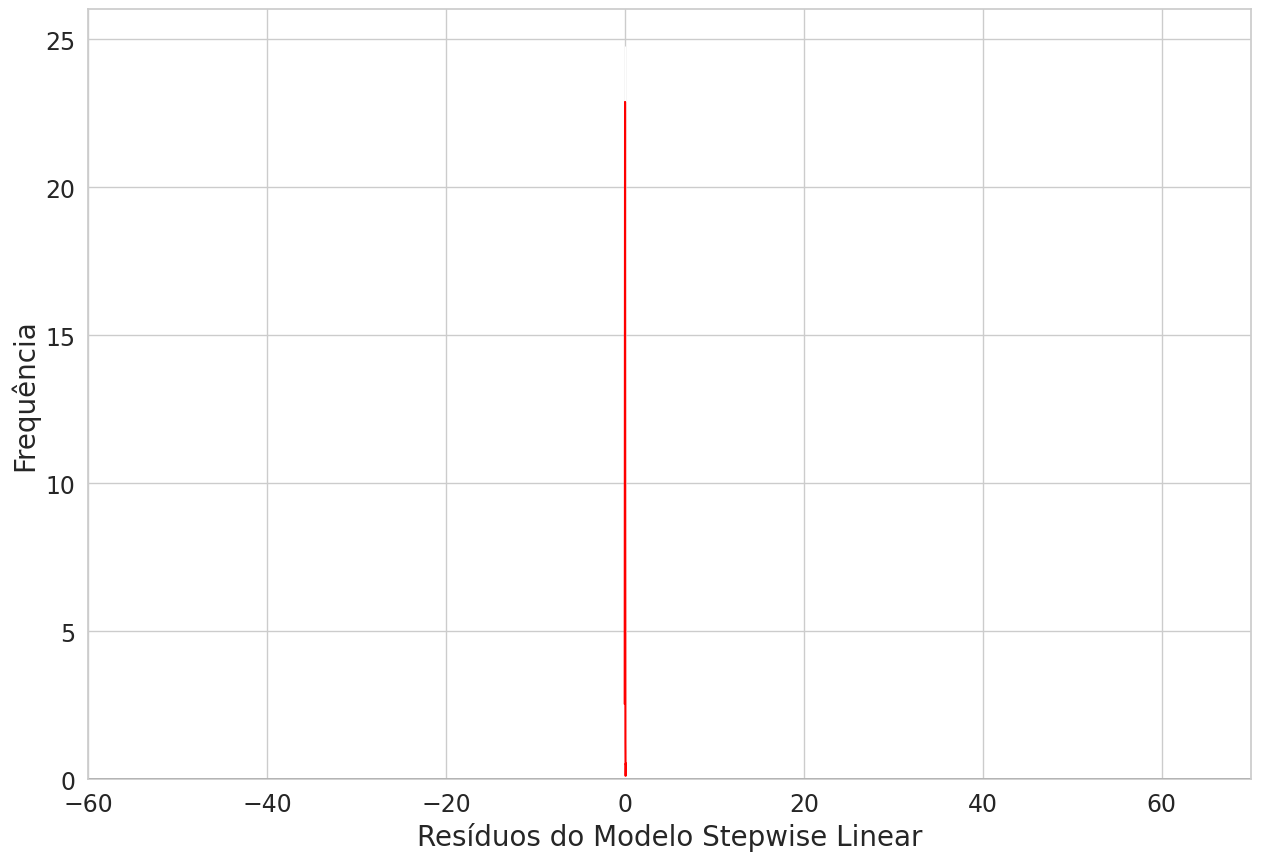

In [ ]:
# Calcula os valores de ajuste da distribuição normal
(mu, sigma) = norm.fit(modelo_step_planosaude.resid)

# Gráfico propriamente dito
plt.figure(figsize=(15,10))
sns.histplot(modelo_step_planosaude.resid, bins=15, kde=True, stat="density",
             color='red', alpha=0.4)
plt.xlim(-60, 70)
x = np.linspace(-60, 70, 100)
p = norm.pdf(x, mu, sigma)
plt.plot(x, p, 'k', linewidth=2)
plt.xlabel('Resíduos do Modelo Stepwise Linear', fontsize=20)
plt.ylabel('Frequência', fontsize=20)
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.show()

In [ ]:
# In[8.8]: Função para o teste de Breusch-Pagan para a elaboração de diagnóstico
#de heterocedasticidade

# Criação da função 'breusch_pagan_test'

def breusch_pagan_test(modelo):

    df = pd.DataFrame({'yhat':modelo.fittedvalues,
                       'resid':modelo.resid})

    df['up'] = (np.square(df.resid))/np.sum(((np.square(df.resid))/df.shape[0]))

    modelo_aux = sm.OLS.from_formula('up ~ yhat', df).fit()

    anova_table = sm.stats.anova_lm(modelo_aux, typ=2)

    anova_table['sum_sq'] = anova_table['sum_sq']/2

    chisq = anova_table['sum_sq'].iloc[0]

    p_value = stats.chi2.pdf(chisq, 1)*2

    print(f"chisq: {chisq}")

    print(f"p-value: {p_value}")

    return chisq, p_value

# In[8.9]: Teste de Breusch-Pagan propriamente dito

breusch_pagan_test(modelo_step_planosaude)
# Presença de heterocedasticidade -> omissão de variável(is) explicativa(s)
#relevante(s)

# H0 do teste: ausência de heterocedasticidade.
# H1 do teste: heterocedasticidade, ou seja, correlação entre resíduos e
#uma ou mais variáveis explicativas, o que indica omissão de variável relevante!

# Interpretação
teste_bp = breusch_pagan_test(modelo_step_planosaude) #criação do objeto 'teste_bp'
chisq, p = teste_bp #definição dos elementos contidos no objeto 'teste_bp'
alpha = 0.05 #nível de significância
if p > alpha:
    print('Não se rejeita H0 - Ausência de Heterocedasticidade')
else:
	print('Rejeita-se H0 - Existência de Heterocedasticidade')


chisq: 15.634378519388346
p-value: 8.127137188657636e-05
chisq: 15.634378519388346
p-value: 8.127137188657636e-05
Rejeita-se H0 - Existência de Heterocedasticidade


In [ ]:
# In[8.10]: Adicionando fitted values e resíduos do 'modelo_step_planosaude'
#no dataframe 'df_regressao_linear_dummies'

df_regressao_linear_dummies['fitted_step'] = modelo_step_planosaude.fittedvalues
df_regressao_linear_dummies['residuos_step'] = modelo_step_planosaude.resid
df_regressao_linear_dummies

,absenteismo,rotatividade,tempo_casa,escala_6x1,cargo_Atendente_De_Lanchonete,cargo_Auxiliar_De_Cozinha,cargo_Auxiliar_De_Expedicao,cargo_Auxiliar_De_Higienizacao,cargo_Auxiliar_De_Limpeza,cargo_Auxiliar_Massas_Conf_Panificacao,...,cargo_Meio_Oficial_Cozinheiro,cargo_Motorista,cargo_Nutricionista_Supervisor_Operacional,cargo_Padeiro,cargo_Supervisor_Operacional,ano_2024,ano_2025,ano_2026,fitted_step,residuos_step
0,0.0134,0.0000,9.52,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.016726,-0.003326
1,0.0233,0.6250,8.40,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0.041436,-0.018136
2,0.0211,0.0486,9.40,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0.018715,0.002385
3,0.0111,0.0417,13.03,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0.011000,0.000100
4,0.0000,0.0000,1.25,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.033739,-0.033739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,0.0075,0.0213,5.39,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,-0.003620,0.011120
128,0.0267,0.4250,0.77,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0.020356,0.006344
129,0.0015,0.7778,0.91,1,0,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0.032716,-0.031216
130,0.0066,0.6357,0.72,1,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0.028012,-0.021412


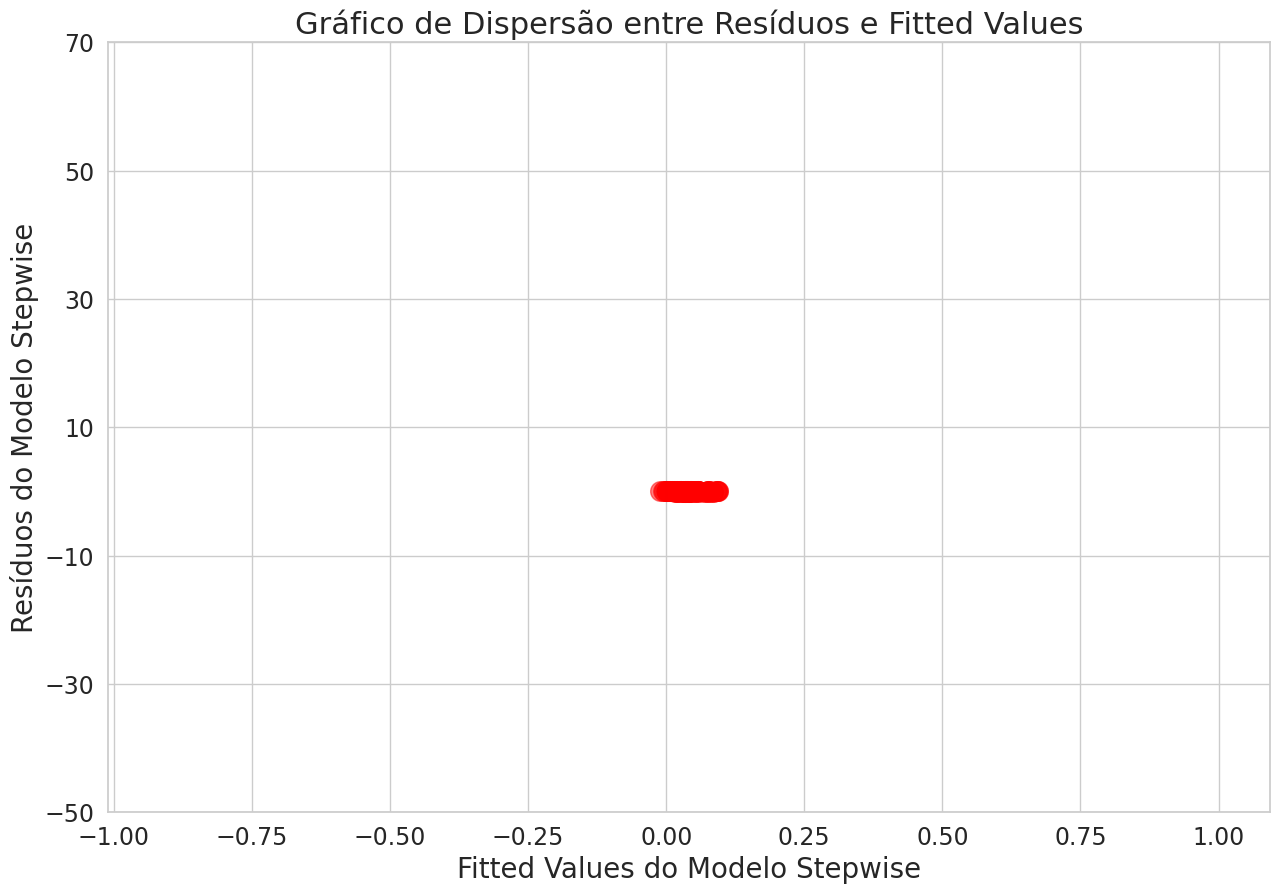

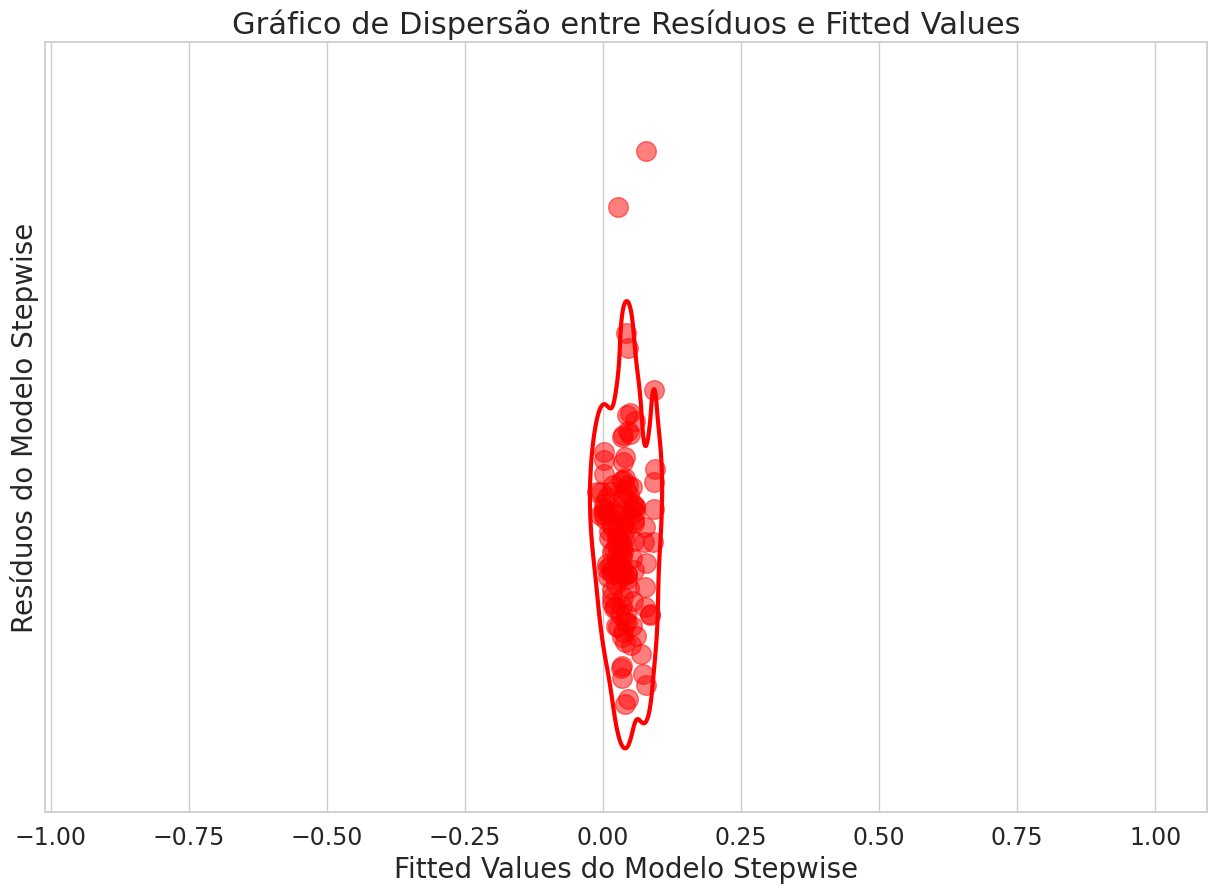

In [ ]:
# In[8.11]: Gráfico que relaciona resíduos e fitted values do
#'modelo_step_planosaude'

plt.figure(figsize=(15,10))
sns.regplot(x='fitted_step', y='residuos_step', data=df_regressao_linear_dummies,
            marker='o', fit_reg=False,
            scatter_kws={"color":'red', 'alpha':0.5, 's':200})
plt.title('Gráfico de Dispersão entre Resíduos e Fitted Values', fontsize=22)
plt.xlabel('Fitted Values do Modelo Stepwise', fontsize=20)
plt.ylabel('Resíduos do Modelo Stepwise', fontsize=20)
plt.xticks(fontsize=17)
plt.yticks(np.arange(-50, 71, 20), fontsize=17)
x_min = df_regressao_linear_dummies['fitted_step'].min()-1
x_max = df_regressao_linear_dummies['fitted_step'].max()+1
plt.xlim(x_min, x_max)
plt.show()

# In[8.12]: Gráfico que relaciona resíduos e fitted values do
#'modelo_step_planosaude', com boundaries

plt.figure(figsize=(15,10))
sns.regplot(x='fitted_step', y='residuos_step', data=df_regressao_linear_dummies,
            marker='o', fit_reg=False,
            scatter_kws={"color":'red', 'alpha':0.5, 's':200})
plt.title('Gráfico de Dispersão entre Resíduos e Fitted Values', fontsize=22)
plt.xlabel('Fitted Values do Modelo Stepwise', fontsize=20)
plt.ylabel('Resíduos do Modelo Stepwise', fontsize=20)
plt.xticks(fontsize=17)
plt.yticks(np.arange(-50, 71, 20), fontsize=17)
x_min = df_regressao_linear_dummies['fitted_step'].min()-1
x_max = df_regressao_linear_dummies['fitted_step'].max()+1
plt.xlim(x_min, x_max)

sns.kdeplot(data=df_regressao_linear_dummies, x='fitted_step', y='residuos_step',
            levels=2, color='red', linewidths=3)

plt.show()

In [ ]:
df_regressao_linear_dummies['absenteismo'] = df_regressao_linear_dummies['absenteismo'] + 0.00001

In [ ]:
# In[8.13]: Transformação de Box-Cox

# Para o cálculo do lambda de Box-Cox
from scipy.stats import boxcox

# 'yast' é uma variável que traz os valores transformados (Y*)
# 'lmbda' é o lambda de Box-Cox
yast, lmbda = boxcox(df_regressao_linear_dummies['absenteismo'])

print("Lambda: ",lmbda)

# In[8.14]: Inserindo o lambda de Box-Cox no dataset para a estimação de um
#novo modelo

df_regressao_linear_dummies['bc_despmed'] = yast
df_regressao_linear_dummies

# Verificação do cálculo, apenas para fins didáticos
df_regressao_linear_dummies['bc_despmed2'] = ((df_regressao_linear_dummies['absenteismo'])**\
                                        (lmbda) - 1) / (lmbda)
df_regressao_linear_dummies

del df_regressao_linear_dummies['bc_despmed2']

,absenteismo,rotatividade,tempo_casa,escala_6x1,cargo_Atendente_De_Lanchonete,cargo_Auxiliar_De_Cozinha,cargo_Auxiliar_De_Expedicao,cargo_Auxiliar_De_Higienizacao,cargo_Auxiliar_De_Limpeza,cargo_Auxiliar_Massas_Conf_Panificacao,...,cargo_Motorista,cargo_Nutricionista_Supervisor_Operacional,cargo_Padeiro,cargo_Supervisor_Operacional,ano_2024,ano_2025,ano_2026,fitted_step,residuos_step,bc_despmed
0,0.01341,0.0000,9.52,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.016726,-0.003326,-1.949865
1,0.02331,0.6250,8.40,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0.041436,-0.018136,-1.853636
2,0.02111,0.0486,9.40,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0.018715,0.002385,-1.872631
3,0.01111,0.0417,13.03,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0.011000,0.000100,-1.977691
4,0.00001,0.0000,1.25,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.033739,-0.033739,-2.289221
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,0.00751,0.0213,5.39,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,-0.003620,0.011120,-2.028809
128,0.02671,0.4250,0.77,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0.020356,0.006344,-1.826179
129,0.00151,0.7778,0.91,1,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0.032716,-0.031216,-2.167209
130,0.00661,0.6357,0.72,1,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0.028012,-0.021412,-2.043680


In [ ]:
# In[8.15]: Estimando um novo modelo com todas as variáveis e a variável
#dependente transformada
# Definição da fórmula utilizada no modelo
lista_colunas = list(df_regressao_linear_dummies.drop(columns=['bc_despmed']).columns)
formula_dummies_modelo = ' + '.join(lista_colunas)
formula_dummies_modelo = "bc_despmed ~ " + formula_dummies_modelo

# Estimação
modelo_bc_planosaude = sm.OLS.from_formula(formula_dummies_modelo,
                                        df_regressao_linear_dummies).fit()

# Parâmetros do modelo
modelo_planosaude.summary()

# In[8.16]: Procedimento Stepwise no 'modelo_bc_planosaude'

modelo_step_bc_planosaude = stepwise(modelo_bc_planosaude, pvalue_limit=0.05)

Regression type: OLS 

Estimating model...: 
 bc_despmed ~ Q('absenteismo') + Q('rotatividade') + Q('tempo_casa') + Q('escala_6x1') + Q('cargo_Atendente_De_Lanchonete') + Q('cargo_Auxiliar_De_Cozinha') + Q('cargo_Auxiliar_De_Expedicao') + Q('cargo_Auxiliar_De_Higienizacao') + Q('cargo_Auxiliar_De_Limpeza') + Q('cargo_Auxiliar_Massas_Conf_Panificacao') + Q('cargo_Auxiliar_Servicos_Gerais') + Q('cargo_Cozinheiro') + Q('cargo_Cozinheiro_Chefe') + Q('cargo_Encarregado_Operacional') + Q('cargo_Estoquista') + Q('cargo_Meio_Oficial_Cozinheiro') + Q('cargo_Motorista') + Q('cargo_Nutricionista_Supervisor_Operacional') + Q('cargo_Padeiro') + Q('cargo_Supervisor_Operacional') + Q('ano_2024') + Q('ano_2025') + Q('ano_2026') + Q('fitted_step') + Q('residuos_step') + Q('fitted_step_bc') + Q('residuos_step_bc')

 Discarding atribute "Q('cargo_Auxiliar_Servicos_Gerais')" with p-value equal to 0.9886235581795602 

Estimating model...: 
 bc_despmed ~ Q('absenteismo') + Q('rotatividade') + Q('tempo_casa'

In [ ]:
# In[8.17]: Teste de verificação da aderência à normalidade dos resíduos do novo
#'modelo_step_bc_planosaude'

# Teste de Shapiro-Francia: interpretação
teste_sf = shapiro_francia(modelo_step_bc_planosaude.resid) #criação do objeto 'teste_sf'
teste_sf = teste_sf.items() #retorna o grupo de pares de valores-chave no dicionário
method, statistics_W, statistics_z, p = teste_sf #definição dos elementos da lista (tupla)
print('Statistics W=%.5f, p-value=%.6f' % (statistics_W[1], p[1]))
alpha = 0.05 #nível de significância
if p[1] > alpha:
	print('Não se rejeita H0 - Distribuição aderente à normalidade')
else:
	print('Rejeita-se H0 - Distribuição não aderente à normalidade')

# In[8.18]: Histograma dos resíduos do 'modelo_step_bc_planosaude' com curva
#normal teórica para comparação das distribuições
# Kernel density estimation (KDE) - forma não-paramétrica para estimação da
#função densidade de probabilidade de determinada variável

method  :  Shapiro-Francia normality test
statistics W  :  0.7986683610366125
statistics z  :  6.316377349106053
p-value  :  1.3388288679651773e-10
Statistics W=0.79867, p-value=0.000000
Rejeita-se H0 - Distribuição não aderente à normalidade


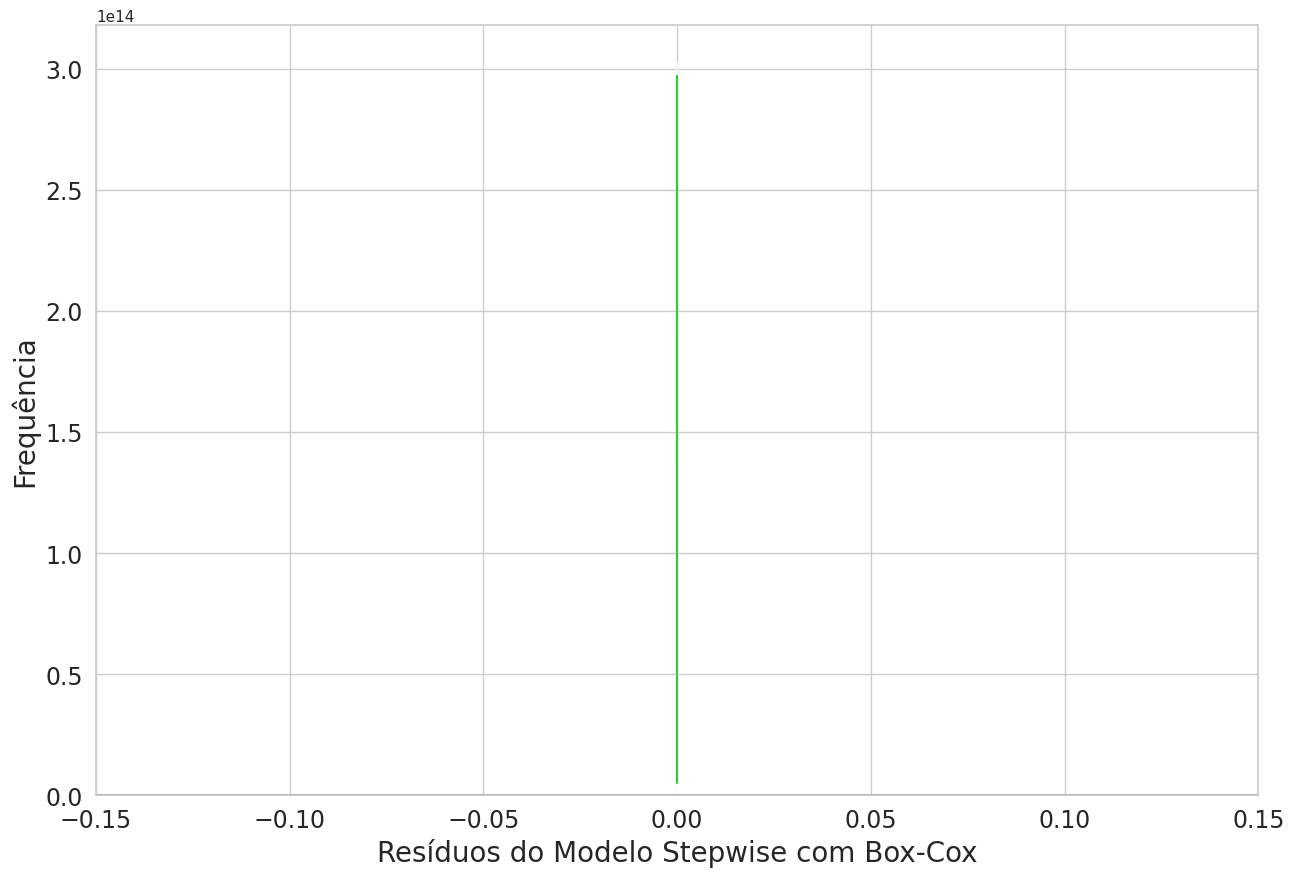

In [ ]:
from scipy.stats import norm

# Calcula os valores de ajuste da distribuição normal
(mu, sigma) = norm.fit(modelo_step_bc_planosaude.resid)

# Gráfico propriamente dito
plt.figure(figsize=(15,10))
sns.histplot(modelo_step_bc_planosaude.resid, bins=15, kde=True, stat="density",
             color='limegreen', alpha=0.4)
plt.xlim(-0.15, 0.15)
x = np.linspace(-0.15, 0.15, 100)
p = norm.pdf(x, mu, sigma)
plt.plot(x, p, 'k', linewidth=2)
plt.xlabel('Resíduos do Modelo Stepwise com Box-Cox', fontsize=20)
plt.ylabel('Frequência', fontsize=20)
plt.xticks(fontsize=17)
plt.yticks(fontsize=17)
plt.show()

In [ ]:
# In[8.19]: Teste de Breusch-Pagan para diagnóstico de heterocedasticidade
#no 'modelo_step_bc_planosaude'

breusch_pagan_test(modelo_step_bc_planosaude)

# Interpretação
teste_bp = breusch_pagan_test(modelo_step_bc_planosaude) #criação do objeto 'teste_bp'
chisq, p = teste_bp #definição dos elementos contidos no objeto 'teste_bp'
alpha = 0.05 #nível de significância
if p > alpha:
    print('Não se rejeita H0 - Ausência de Heterocedasticidade')
else:
	print('Rejeita-se H0 - Existência de Heterocedasticidade')

chisq: 4.329316808816095
p-value: 0.04401808831828705
chisq: 4.329316808816095
p-value: 0.04401808831828705
Rejeita-se H0 - Existência de Heterocedasticidade


In [ ]:
# In[8.20]: Adicionando fitted values e resíduos do 'modelo_step_bc_planosaude'
#no dataframe 'df_regressao_linear_dummies'

df_regressao_linear_dummies['fitted_step_bc'] = modelo_step_bc_planosaude.fittedvalues
df_regressao_linear_dummies['residuos_step_bc'] = modelo_step_bc_planosaude.resid
df_regressao_linear_dummies

,absenteismo,rotatividade,tempo_casa,escala_6x1,cargo_Atendente_De_Lanchonete,cargo_Auxiliar_De_Cozinha,cargo_Auxiliar_De_Expedicao,cargo_Auxiliar_De_Higienizacao,cargo_Auxiliar_De_Limpeza,cargo_Auxiliar_Massas_Conf_Panificacao,...,cargo_Padeiro,cargo_Supervisor_Operacional,ano_2024,ano_2025,ano_2026,fitted_step,residuos_step,bc_despmed,fitted_step_bc,residuos_step_bc
0,0.01341,0.0000,9.52,0,0,0,0,0,0,0,...,0,0,0,0,0,0.016726,-0.003326,-1.949865,-1.949865,-9.325873e-15
1,0.02331,0.6250,8.40,0,0,0,0,0,0,0,...,0,0,1,0,0,0.041436,-0.018136,-1.853636,-1.853636,-8.659740e-15
2,0.02111,0.0486,9.40,0,0,0,0,0,0,0,...,0,0,0,1,0,0.018715,0.002385,-1.872631,-1.872631,-9.103829e-15
3,0.01111,0.0417,13.03,0,0,0,0,0,0,0,...,0,0,0,0,1,0.011000,0.000100,-1.977691,-1.977691,-1.110223e-14
4,0.00001,0.0000,1.25,1,0,0,0,0,0,0,...,0,0,0,0,0,0.033739,-0.033739,-2.289221,-2.289221,-5.329071e-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127,0.00751,0.0213,5.39,0,0,0,0,0,0,0,...,0,1,0,0,1,-0.003620,0.011120,-2.028809,-2.028809,-8.437695e-15
128,0.02671,0.4250,0.77,1,0,0,0,0,0,0,...,0,1,0,0,0,0.020356,0.006344,-1.826179,-1.826179,-6.217249e-15
129,0.00151,0.7778,0.91,1,0,0,0,0,0,0,...,0,1,1,0,0,0.032716,-0.031216,-2.167209,-2.167209,-5.773160e-15
130,0.00661,0.6357,0.72,1,0,0,0,0,0,0,...,0,1,0,1,0,0.028012,-0.021412,-2.043680,-2.043680,-5.773160e-15


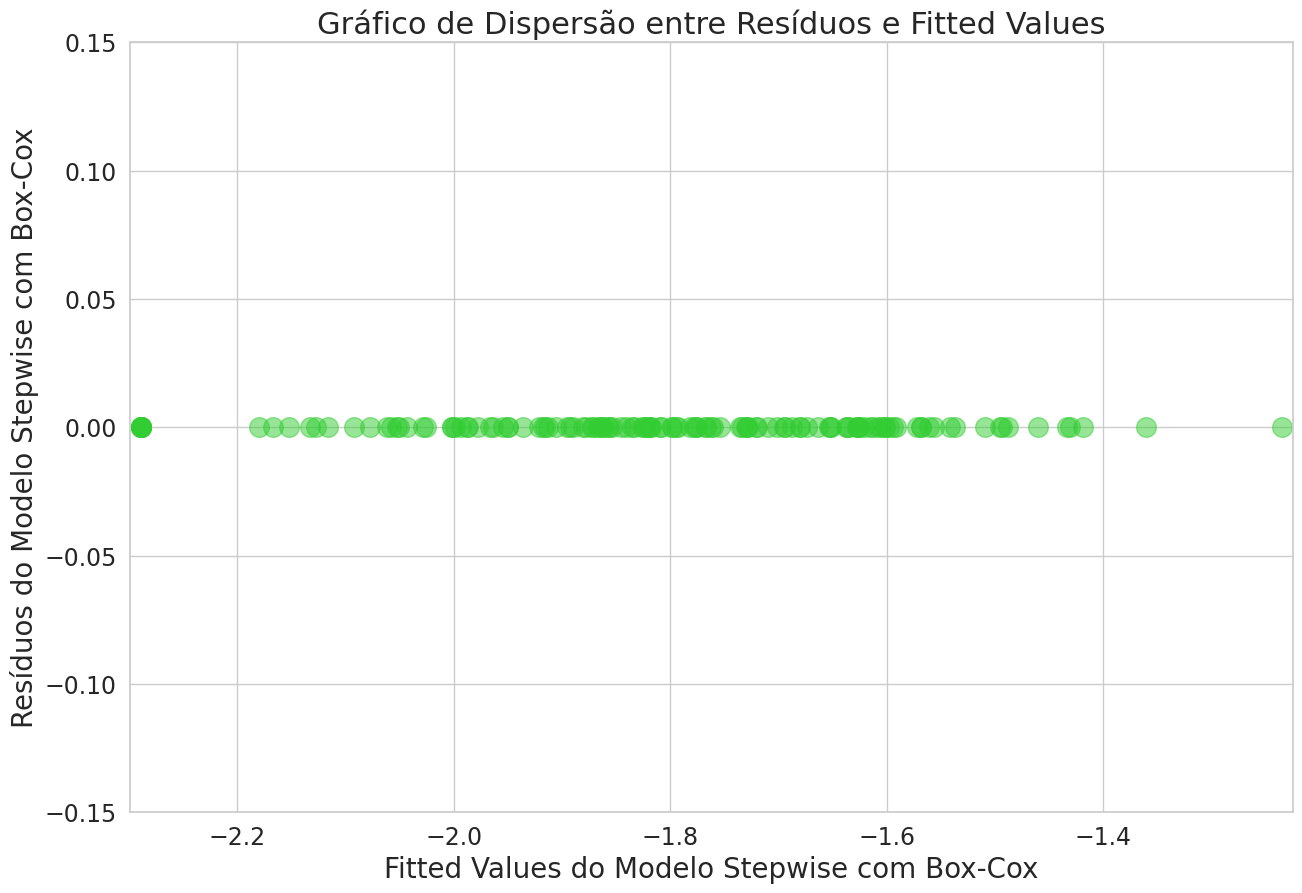

In [ ]:
# In[8.21]: Gráfico que relaciona resíduos e fitted values do
#'modelo_step_bc_planosaude'

plt.figure(figsize=(15,10))
sns.regplot(x='fitted_step_bc', y='residuos_step_bc', data=df_regressao_linear_dummies,
            marker='o', fit_reg=False,
            scatter_kws={"color":'limegreen', 'alpha':0.5, 's':200})
plt.title('Gráfico de Dispersão entre Resíduos e Fitted Values', fontsize=22)
plt.xlabel('Fitted Values do Modelo Stepwise com Box-Cox', fontsize=20)
plt.ylabel('Resíduos do Modelo Stepwise com Box-Cox', fontsize=20)
plt.xticks(fontsize=17)
plt.yticks(np.arange(-.15, .16, .05), fontsize=17)
x_min = df_regressao_linear_dummies['fitted_step_bc'].min()-0.01
x_max = df_regressao_linear_dummies['fitted_step_bc'].max()+0.01
plt.xlim(x_min, x_max)
plt.show()

<Axes: title={'center': 'Gráfico de Dispersão entre Resíduos e Fitted Values'}, xlabel='Fitted Values do Modelo Stepwise com Box-Cox', ylabel='Resíduos do Modelo Stepwise com Box-Cox'>

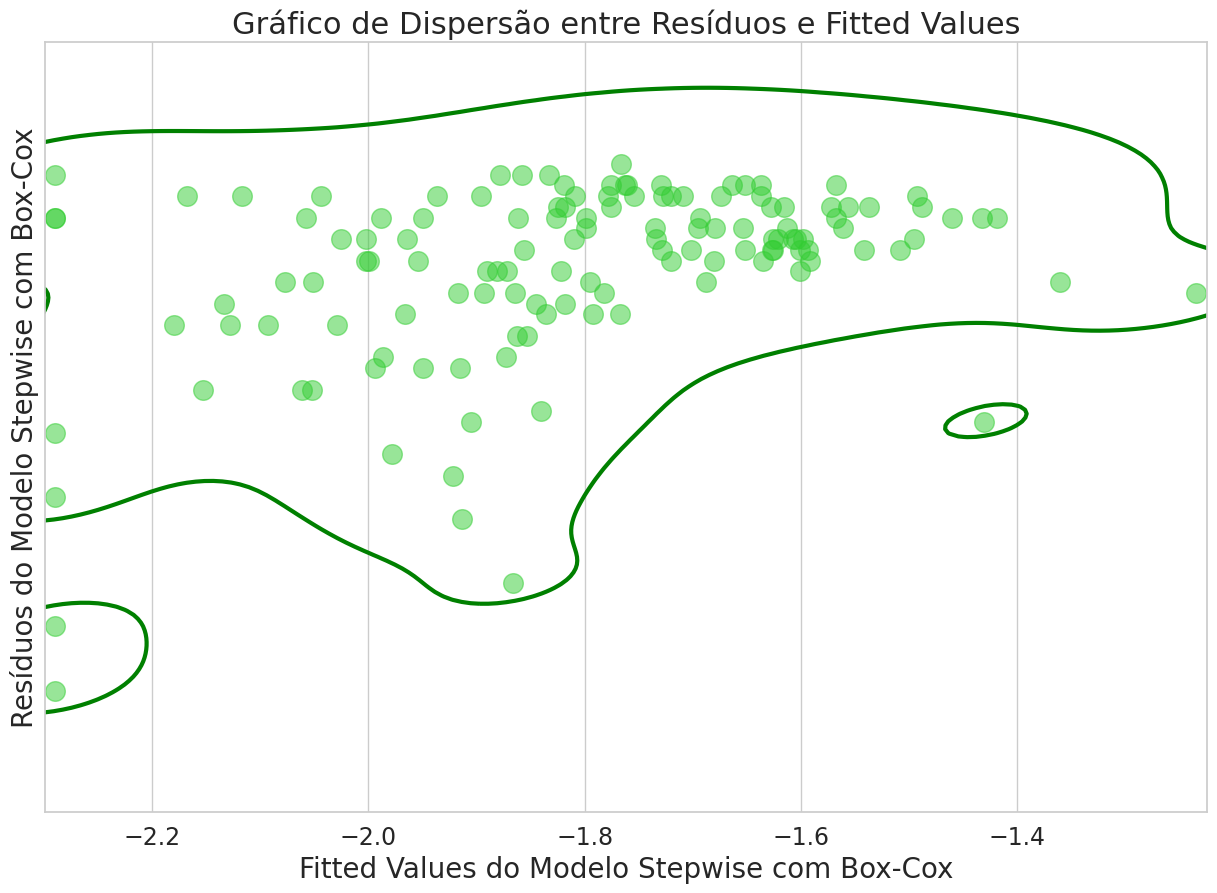

In [ ]:
# In[8.22]: Gráfico que relaciona resíduos e fitted values do
#'modelo_step_bc_planosaude', com boundaries

plt.figure(figsize=(15, 10))
sns.regplot(x='fitted_step_bc', y='residuos_step_bc', data=df_regressao_linear_dummies,
            marker='o', fit_reg=False,
            scatter_kws={"color": 'limegreen', 'alpha': 0.5, 's': 200})
plt.title('Gráfico de Dispersão entre Resíduos e Fitted Values', fontsize=22)
plt.xlabel('Fitted Values do Modelo Stepwise com Box-Cox', fontsize=20)
plt.ylabel('Resíduos do Modelo Stepwise com Box-Cox', fontsize=20)
plt.xticks(fontsize=17)
plt.yticks(np.arange(-.15, .16, .05), fontsize=17)
x_min = df_regressao_linear_dummies['fitted_step_bc'].min()-0.01
x_max = df_regressao_linear_dummies['fitted_step_bc'].max()+0.01
plt.xlim(x_min, x_max)

sns.kdeplot(data=df_regressao_linear_dummies, x='fitted_step_bc', y='residuos_step_bc',
            levels=2, color='green', linewidths=3)